# 🏠 Ames Housing: Automated Valuation & Pricing Engine

## 🚨 The Business Problem
In the residential real estate market, setting property prices relies on manual, subjective appraisals. This leads to inconsistency, costly mispricing risks, and operational latency.

## 💡 The Proposed Solution
An objective, data-driven real estate intelligence system structured around two lenses:
1. **Primary Lens (Predictive):** Automated Valuation & Pricing Engine (Predicting `SalePrice`).
2. **Secondary Lens (Diagnostic):** Market Segmentation to group properties into structural tiers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Set plot style
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## Step 1: Load the Data
We load the raw training dataset to begin our diagnostic analysis.

In [2]:
df = pd.read_csv('../data/raw/train.csv')
print(f"Dataset Loaded. Shape: {df.shape}")
display(df.head())

Dataset Loaded. Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Step 2: Diagnostic First-Pass
Before splitting, we perform a high-level health check on the dataset to understand missing values, data types, and the distribution of our target variable (`SalePrice`).

 1. BASIC SHAPE & DUPLICATES
Total Rows (Houses): 1460
Total Columns (Features): 81
Duplicate Rows: 0


 2. MISSING DATA SEVERITY REPORT


,Missing Values,Percentage (%)
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945




 3. FEATURE TYPE SEPARATION
Numerical Features: 38
Categorical Features: 43


 4. TARGET VARIABLE DISTRIBUTION (SalePrice)


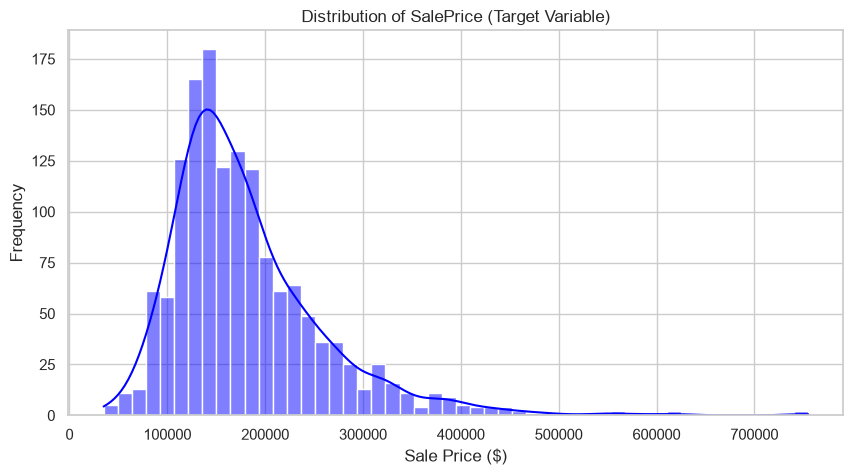

In [3]:
print("======================================================")
print(" 1. BASIC SHAPE & DUPLICATES")
print("======================================================")
print(f"Total Rows (Houses): {df.shape[0]}")
print(f"Total Columns (Features): {df.shape[1]}")
print(f"Duplicate Rows: {df.duplicated().sum()}")
print("\n")

print("======================================================")
print(" 2. MISSING DATA SEVERITY REPORT")
print("======================================================")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_percent = (missing / df.shape[0]) * 100
missing_report = pd.DataFrame({'Missing Values': missing, 'Percentage (%)': missing_percent})
display(missing_report.head(10))
print("\n")

print("======================================================")
print(" 3. FEATURE TYPE SEPARATION")
print("======================================================")
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"Numerical Features: {len(numeric_cols)}")
print(f"Categorical Features: {len(categorical_cols)}")
print("\n")

print("======================================================")
print(" 4. TARGET VARIABLE DISTRIBUTION (SalePrice)")
print("======================================================")
plt.figure(figsize=(10, 5))
sns.histplot(df['SalePrice'], kde=True, bins=50, color='blue')
plt.title('Distribution of SalePrice (Target Variable)')
plt.xlabel('Sale Price ($)')
plt.ylabel('Frequency')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

## Step 3: Train/Test Split (Preventing Data Leakage)
Before we perform deep Exploratory Data Analysis (EDA) or impute missing values, we must separate our target variable and lock away a test set. This ensures our models do not accidentally memorize information from the test data.

**Why a Random Split?**
Because our target variable (`SalePrice`) is a continuous numerical value (Regression), there are no discrete classes to balance. A standard Random Split is the mathematically correct default for this regression task.

In [4]:
# Drop the useless ID column
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

# Separate Target (y) from Features (X)
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

# Execute the Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Data Shape: {X_train.shape}")
print(f"Test Data Shape: {X_test.shape}")

Training Data Shape: (1168, 79)
Test Data Shape: (292, 79)


## **Exploratory Data Analysis (EDA)**

## Phase 1: Univariate Analysis (Distributions)


SalePrice Skewness: 1.74


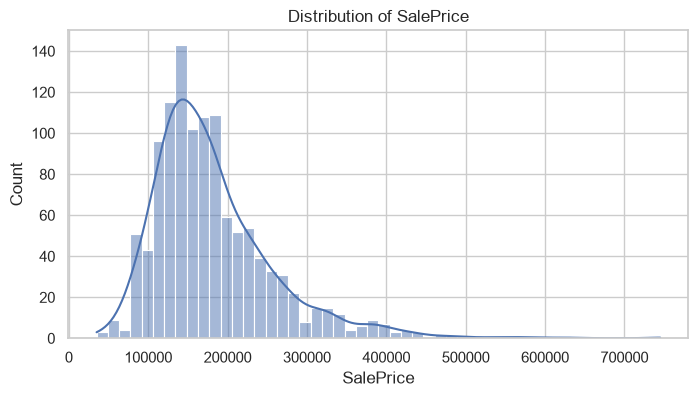

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
# Check the skewness score (Higher than 1 means it has a long tail)
print(f"SalePrice Skewness: {y_train.skew():.2f}")
# Plot the distribution
plt.figure(figsize=(8, 4))
sns.histplot(y_train, kde=True, bins=50)
plt.title('Distribution of SalePrice')
plt.show()

### Conclusion: Target Variable Skewness
**Observation:** The target variable (`SalePrice`) exhibits severe right-skewness, indicated by a long tail. Machine learning models struggle with highly skewed targets as they disproportionately penalize errors on large outliers.

**Preprocessing Action:** Apply a logarithmic transformation (`np.log1p`) to the target variable for both the train and test sets. This pulls the extreme values inward, normalizing the distribution into a stable bell curve.

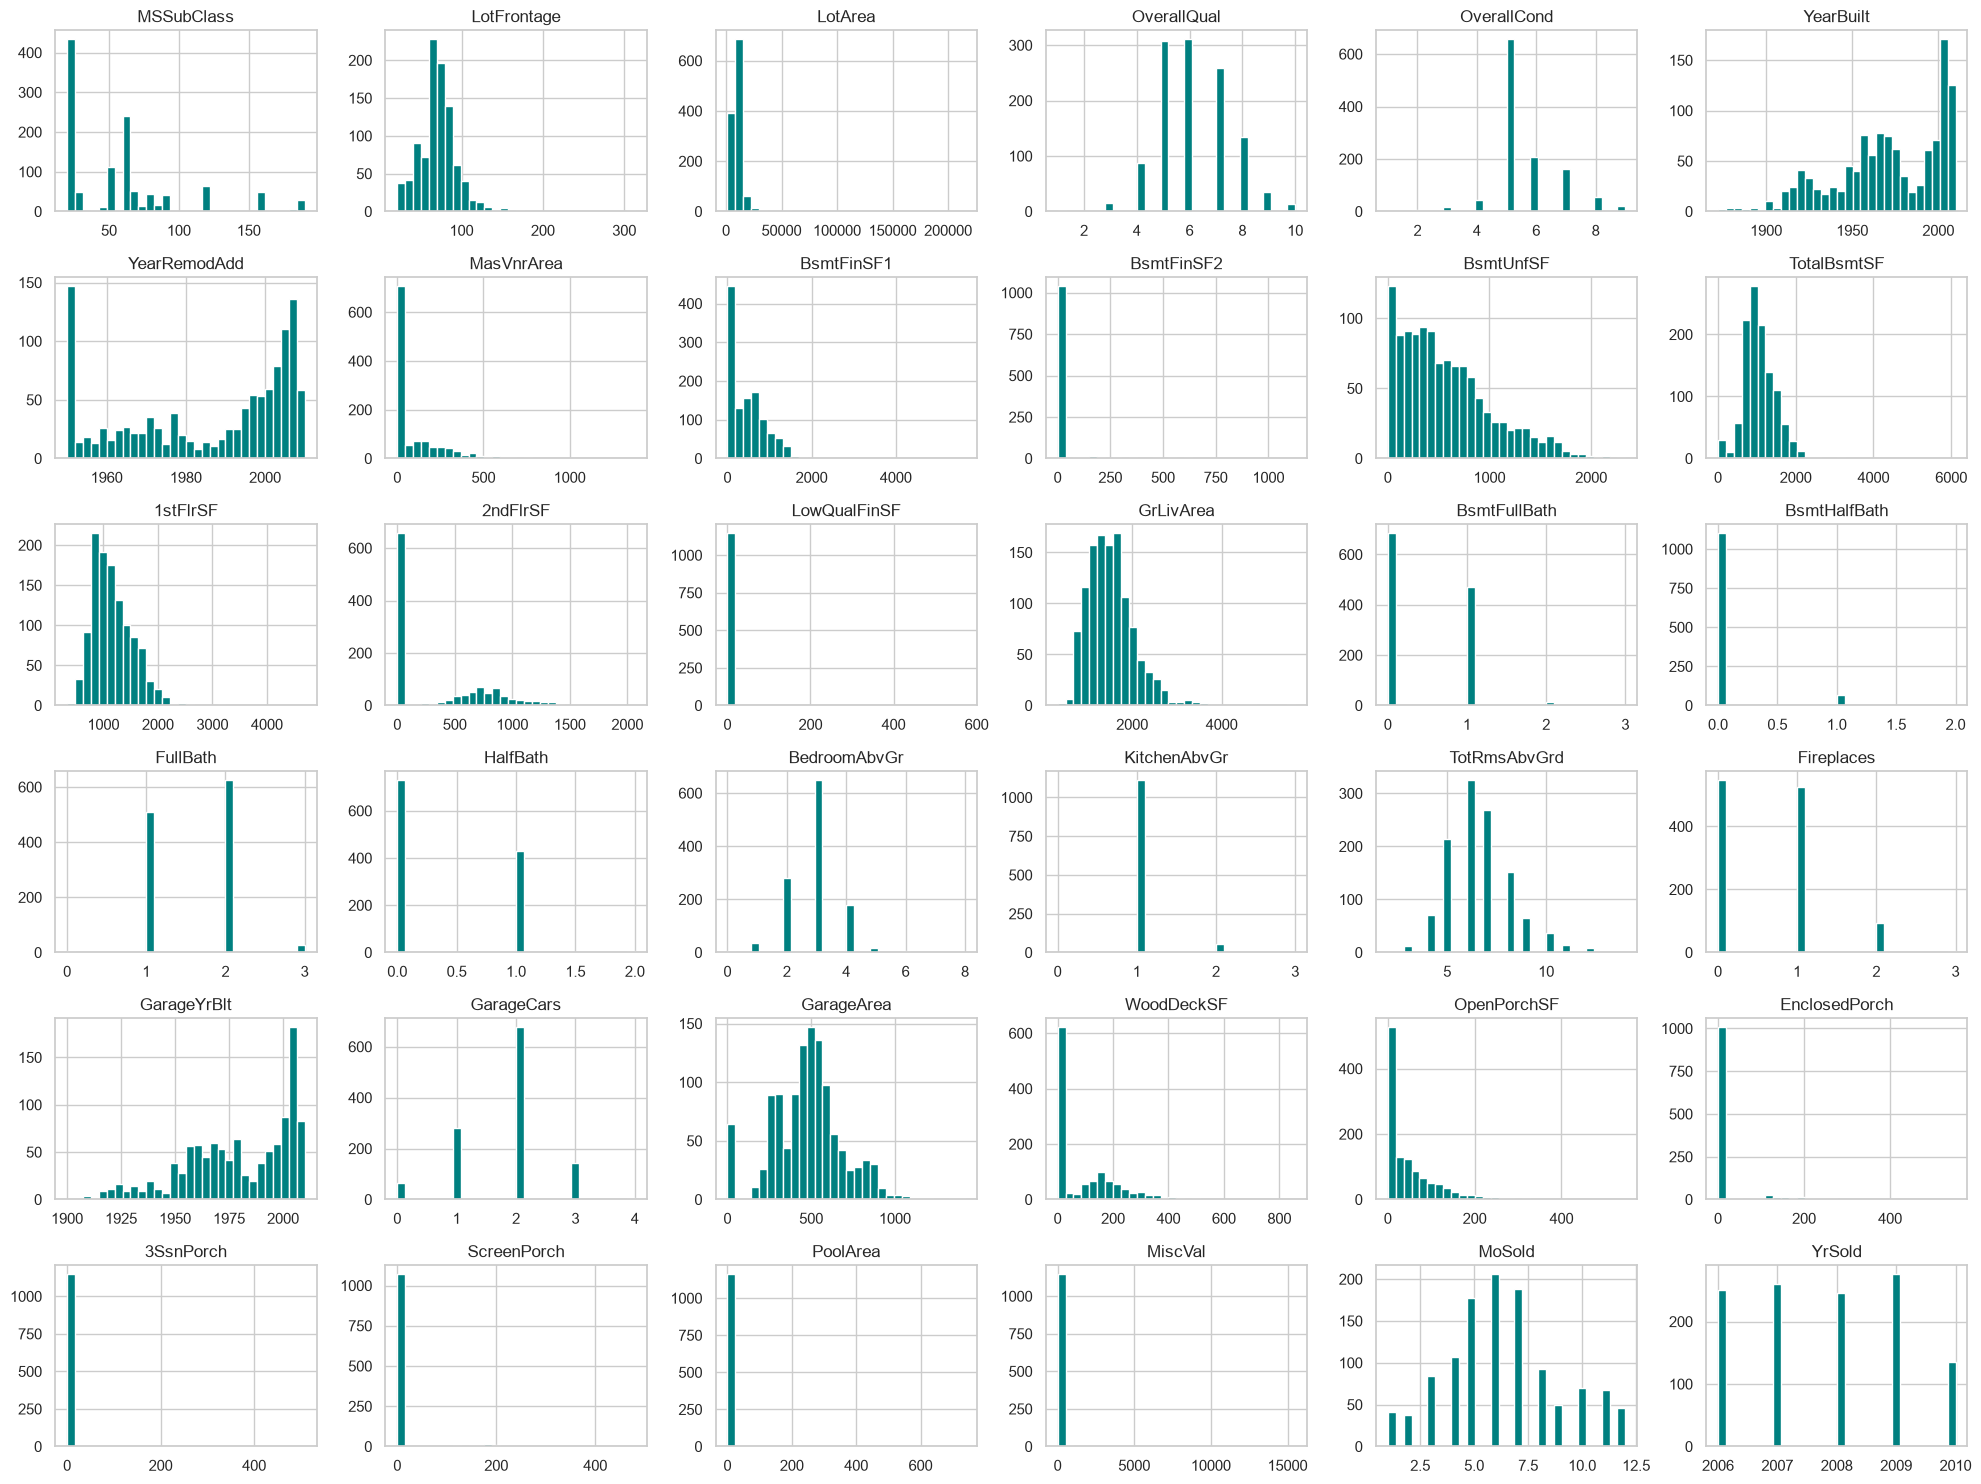

In [6]:


# 1. Select only the numerical columns from X_train
numerical_features = X_train.select_dtypes(include=['int64', 'float64'])

# 2. Use pandas built-in histogram function to plot them all at once!
# We make the figure size large (20x15) so they all fit nicely
numerical_features.hist(figsize=(20, 15), bins=30, color='teal')
plt.tight_layout() # This keeps the titles from overlapping
plt.show()

### Conclusion: Numerical Feature Distributions
**Observation:** We observe a mix of continuous variables (like `LotArea`, which are highly skewed) and discrete variables (like `Fireplaces`, which act as categories/counts). 

**Preprocessing Action:** Continuous features exhibiting high skewness will require mathematical transformations (e.g., Log or Yeo-Johnson). Discrete numerical features will be left untransformed, and columns with almost zero variance (e.g., a single massive spike at zero) will be dropped.

## Phase 2: Missingness Mechanism Diagnostics


In [7]:
# --- PHASE 2: MISSINGNESS MECHANISM REPORT ---
import pandas as pd

# Calculate missing percentages ONLY on X_train
missing_counts = X_train.isnull().sum()
missing_percent = (missing_counts / len(X_train)) * 100

# Filter out complete columns
missing_df = pd.DataFrame({'Missing %': missing_percent}).loc[missing_counts > 0]
missing_df = missing_df.sort_values(by='Missing %', ascending=False)

print("=== MISSING DATA STRATEGY REPORT ===")
print("If missing > 40%, it is almost certainly MNAR (Missing Not At Random - e.g. No Pool, No Alley).")
print("We will likely fill these with 'None' or drop them later.\n")

print(missing_df.round(2).to_string())

print("\n-----------------------------------------")
print("Look closely at the 'Garage' and 'Bsmt' (Basement) variables.")
print("Notice how they often have the exact same missing percentage? ")
print("That's structural! It means if a house doesn't have a basement, ALL basement columns are blank.")

=== MISSING DATA STRATEGY REPORT ===
If missing > 40%, it is almost certainly MNAR (Missing Not At Random - e.g. No Pool, No Alley).
We will likely fill these with 'None' or drop them later.

              Missing %
PoolQC            99.49
MiscFeature       96.06
Alley             93.66
Fence             80.05
MasVnrType        58.48
FireplaceQu       46.83
LotFrontage       18.58
GarageType         5.48
GarageYrBlt        5.48
GarageFinish       5.48
GarageQual         5.48
GarageCond         5.48
BsmtFinType1       2.40
BsmtFinType2       2.40
BsmtExposure       2.40
BsmtCond           2.40
BsmtQual           2.40
MasVnrArea         0.51
Electrical         0.09

-----------------------------------------
Look closely at the 'Garage' and 'Bsmt' (Basement) variables.
Notice how they often have the exact same missing percentage? 
That's structural! It means if a house doesn't have a basement, ALL basement columns are blank.


### Conclusion: Missingness Mechanisms (MCAR vs MNAR)
**Observation:** High-missingness columns (>40%, e.g., `PoolQC`, `Alley`, `Fence`) do not represent randomly missing data (MCAR). They represent structural facts indicating the physical absence of a feature (MNAR).

**Preprocessing Action:** For MNAR columns, we will replace missing values with a designated string (e.g., "None") to create a new category. For normal MCAR numerical values, we will impute using the median.

## Phase 3: Anomaly & Outlier Detection


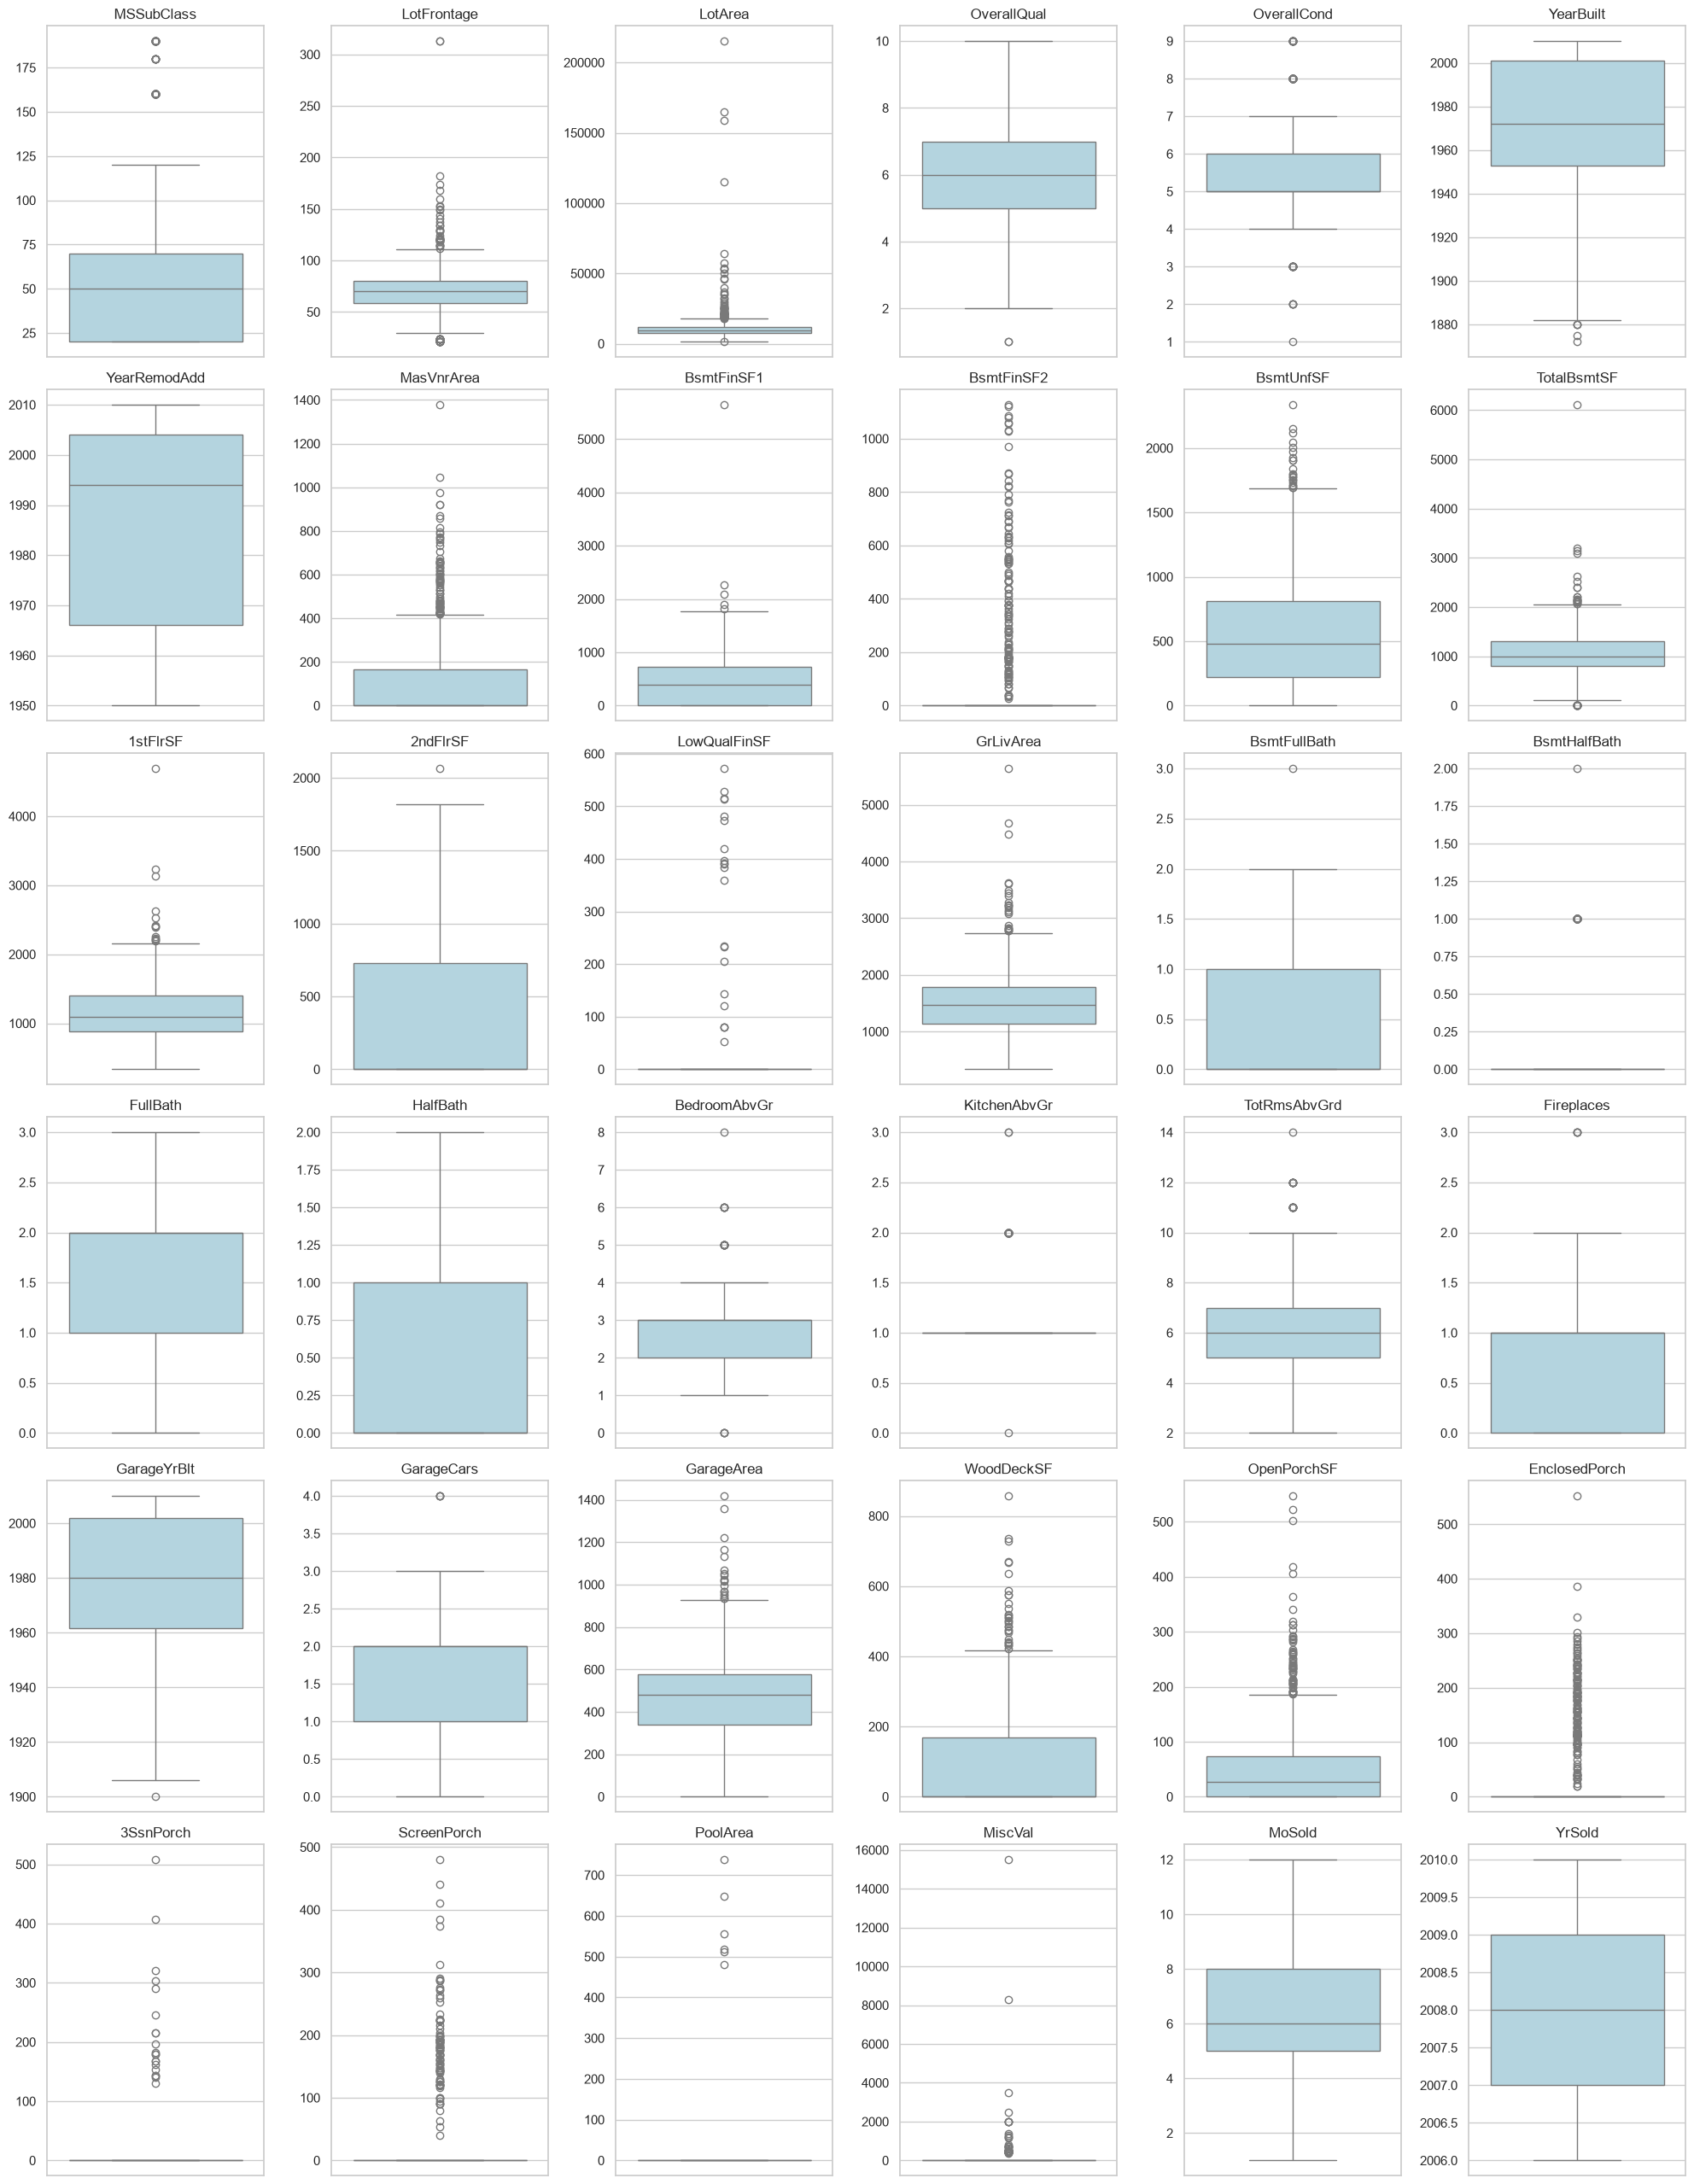

In [8]:
# --- ALL NUMERICAL BOX PLOTS ---
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Grab all the numerical columns
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns

# 2. Set up a massive grid (e.g., 6 columns wide)
fig, axes = plt.subplots(nrows=len(numerical_features) // 6 + 1, ncols=6, figsize=(20, 30))
axes = axes.flatten()

# 3. Loop through and draw a simple box plot for each feature
for i, col in enumerate(numerical_features):
    sns.boxplot(y=X_train[col], ax=axes[i], color='lightblue')
    axes[i].set_title(col)
    axes[i].set_ylabel('') # Keep it clean

# Hide any extra empty charts at the end
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [9]:
# --- AUTOMATED OUTLIER DETECTION (IQR METHOD) ---

# 1. Grab only the continuous numerical features (ignoring discrete ones for now)
# We use standard continuous features for outliers
continuous_features = [col for col in numerical_features if len(X_train[col].unique()) > 20]

outlier_report = {}

# 2. Loop through each feature and apply the IQR math
for col in continuous_features:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define the Whiskers (Standard 1.5x multiplier)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count how many rows fall outside the whiskers
    outliers = X_train[(X_train[col] < lower_bound) | (X_train[col] > upper_bound)]
    
    if len(outliers) > 0:
        outlier_report[col] = len(outliers)

# 3. Print a clean, sorted report
print("=== AUTOMATED OUTLIER REPORT ===")
print("Number of outliers detected per feature:")
for col, count in sorted(outlier_report.items(), key=lambda item: item[1], reverse=True):
    print(f"{col}: {count} outliers")

=== AUTOMATED OUTLIER REPORT ===
Number of outliers detected per feature:
EnclosedPorch: 160 outliers
BsmtFinSF2: 131 outliers
ScreenPorch: 97 outliers
MasVnrArea: 77 outliers
LotFrontage: 68 outliers
OpenPorchSF: 60 outliers
LotArea: 54 outliers
TotalBsmtSF: 47 outliers
WoodDeckSF: 30 outliers
GrLivArea: 23 outliers
BsmtUnfSF: 21 outliers
GarageArea: 18 outliers
1stFlrSF: 13 outliers
YearBuilt: 5 outliers
BsmtFinSF1: 5 outliers
2ndFlrSF: 1 outliers
GarageYrBlt: 1 outliers


### Conclusion: Anomaly and Outlier Detection
**Observation:** The Interquartile Range (IQR) analysis and Box Plots mathematically prove the existence of severe outliers, particularly in continuous features like `GrLivArea` (Above Grade Living Area) and `LotArea`.

**Preprocessing Action:** We will manually drop rows from the training set that contain extreme, impossible physical anomalies (such as `GrLivArea` > 4000 sq ft) to prevent the regression algorithms from learning distorted pricing rules. We will not drop *all* IQR outliers, as some represent natural luxury variance.

## Phase 4: Target Correlation (The Big Hitters)


=== ALL FEATURES CORRELATED WITH SALE PRICE ===
OverallQual      0.785555
GrLivArea        0.695652
GarageCars       0.640991
GarageArea       0.624139
TotalBsmtSF      0.597766
1stFlrSF         0.587883
FullBath         0.552546
TotRmsAbvGrd     0.520388
YearBuilt        0.516501
YearRemodAdd     0.508593
GarageYrBlt      0.480351
MasVnrArea       0.459123
Fireplaces       0.457549
BsmtFinSF1       0.359460
LotFrontage      0.330066
WoodDeckSF       0.329843
2ndFlrSF         0.314030
OpenPorchSF      0.299969
HalfBath         0.280481
LotArea          0.266204
BsmtFullBath     0.226346
BsmtUnfSF        0.222487
BedroomAbvGr     0.156211
ScreenPorch      0.119172
PoolArea         0.115630
3SsnPorch        0.051532
MoSold           0.041890
BsmtFinSF2      -0.005731
YrSold          -0.009099
LowQualFinSF    -0.011189
MiscVal         -0.020179
BsmtHalfBath    -0.048346
OverallCond     -0.074391
MSSubClass      -0.088081
KitchenAbvGr    -0.142785
EnclosedPorch   -0.149532




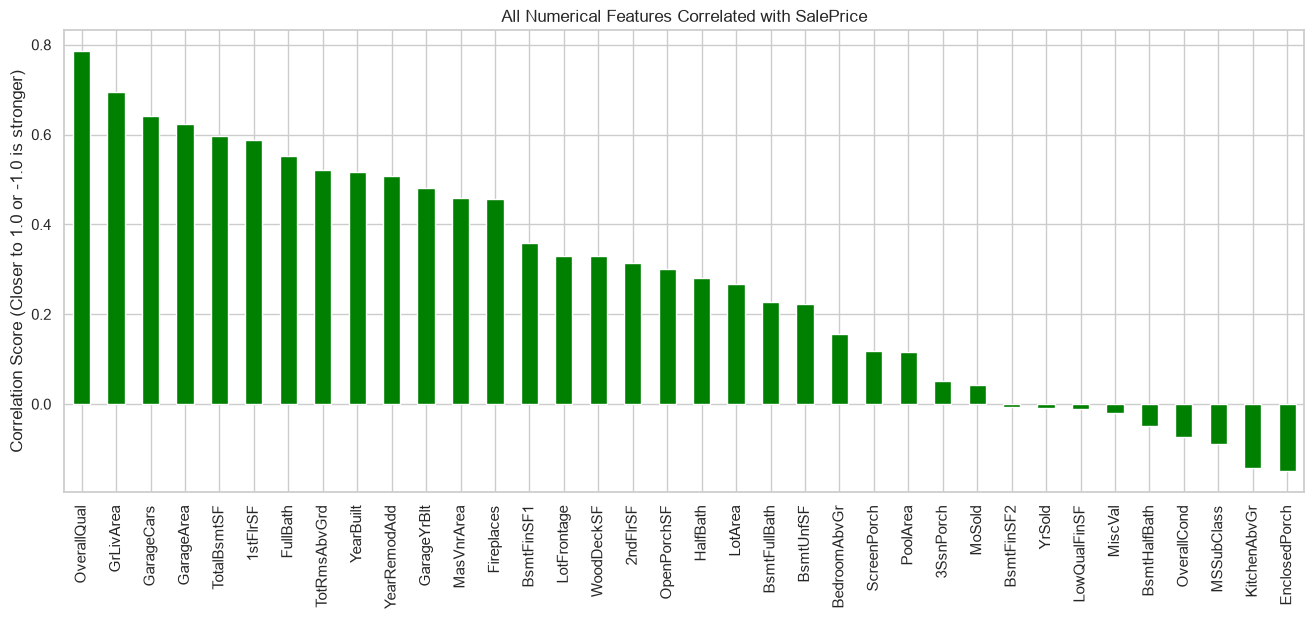

In [10]:
# --- PHASE 4: TARGET CORRELATION (ALL FEATURES) ---
import pandas as pd
import matplotlib.pyplot as plt

# 1. Temporarily combine the numerical features and the target
numerical_data = X_train.select_dtypes(include=['int64', 'float64']).copy()
numerical_data['SalePrice'] = y_train

# 2. Calculate correlation with SalePrice
target_corr = numerical_data.corr()['SalePrice'].sort_values(ascending=False)

# 3. Drop SalePrice correlating with itself
target_corr = target_corr.drop('SalePrice')

# 4. Print EVERY feature's correlation score
print("=== ALL FEATURES CORRELATED WITH SALE PRICE ===")
# to_string() forces pandas to print the whole list without hiding the middle rows
print(target_corr.to_string()) 
print("\n")

# 5. Plot ALL of them on a wide bar chart
plt.figure(figsize=(16, 6)) # Made the graph extra wide to fit all 36+ features
target_corr.plot(kind='bar', color='green')
plt.title('All Numerical Features Correlated with SalePrice')
plt.ylabel('Correlation Score (Closer to 1.0 or -1.0 is stronger)')
plt.xticks(rotation=90) # Rotate text 90 degrees so they fit
plt.show()

### Conclusion: Feature-to-Target Correlation
**Observation:** Features like `OverallQual` and `GrLivArea` show the strongest positive mathematical relationship with `SalePrice`. Conversely, features near 0.000 (like `MoSold`) exhibit almost no predictive relationship.

**Preprocessing Action:** Features with near-zero correlation to the target will be heavily scrutinized and likely dropped to reduce noise and simplify the final model architecture.

## Phase 5: Multivariate Collinearity Analysis


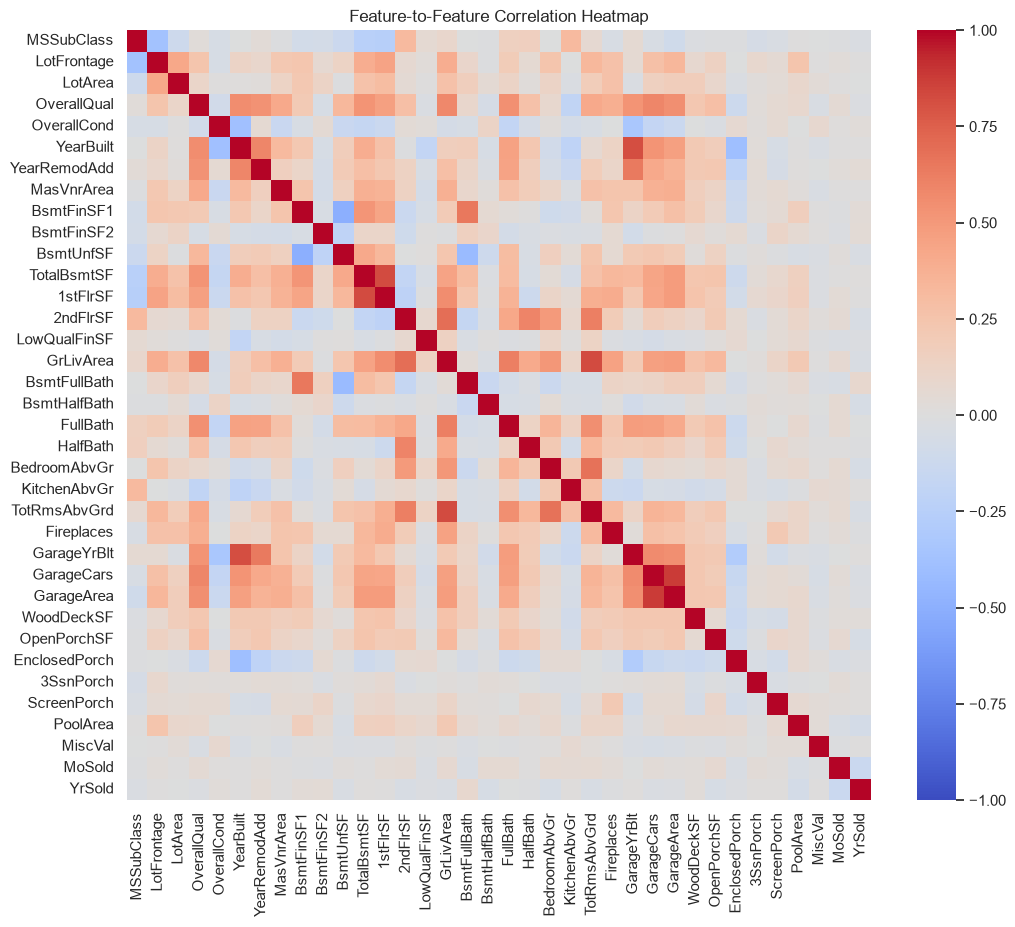

In [11]:
# --- PHASE 5: MULTICOLLINEARITY (HEATMAP) ---
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Grab only the numerical features
numerical_features = X_train.select_dtypes(include=['int64', 'float64'])

# 2. Calculate the correlation matrix
corr_matrix = numerical_features.corr()

# 3. Plot the heatmap (coolwarm makes high correlations dark red)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature-to-Feature Correlation Heatmap')
plt.show()

### Conclusion: Multivariate Collinearity Analysis
**Observation:** The heatmap reveals strong correlations between certain independent features (e.g., `GarageCars` and `GarageArea`), indicating near-perfect multicollinearity.

**Preprocessing Action:** Highly redundant features will be dropped during feature selection. This prevents the destabilization of linear models and ensures feature importance scores in tree-based models are not unnecessarily diluted.

## Phase 6: High-Cardinality Categorical Audits


In [12]:
# --- AUTOMATED RARE CATEGORY SCANNER (ALL TEXT COLUMNS) ---

# 1. Grab all categorical features
categorical_features = X_train.select_dtypes(include=['object']).columns

print("=== RARE CATEGORY REPORT (<10 Houses) ===")

# 2. Loop through every single categorical column
for col in categorical_features:
    counts = X_train[col].value_counts()
    
    # Filter for categories that have fewer than 10 houses
    rare_categories = counts[counts < 10]
    
    # 3. Only print the column if it actually contains rare categories
    if len(rare_categories) > 0:
        print(f"\nFeature: '{col}'")
        
        # Print the exact name of the rare category and how many houses it has
        for cat_name, count in rare_categories.items():
            print(f"  -> '{cat_name}': {count} house(s)")

=== RARE CATEGORY REPORT (<10 Houses) ===

Feature: 'MSZoning'
  -> 'C (all)': 4 house(s)

Feature: 'Street'
  -> 'Grvl': 4 house(s)

Feature: 'LotShape'
  -> 'IR3': 8 house(s)

Feature: 'Utilities'
  -> 'NoSeWa': 1 house(s)

Feature: 'LotConfig'
  -> 'FR3': 3 house(s)

Feature: 'LandSlope'
  -> 'Sev': 9 house(s)

Feature: 'Neighborhood'
  -> 'Veenker': 9 house(s)
  -> 'NPkVill': 7 house(s)
  -> 'Blueste': 1 house(s)

Feature: 'Condition1'
  -> 'PosA': 8 house(s)
  -> 'RRNn': 5 house(s)
  -> 'RRNe': 1 house(s)

Feature: 'Condition2'
  -> 'Feedr': 3 house(s)
  -> 'PosN': 2 house(s)
  -> 'Artery': 2 house(s)
  -> 'RRNn': 1 house(s)
  -> 'PosA': 1 house(s)
  -> 'RRAe': 1 house(s)
  -> 'RRAn': 1 house(s)

Feature: 'HouseStyle'
  -> '2.5Fin': 7 house(s)

Feature: 'RoofStyle'
  -> 'Gambrel': 9 house(s)
  -> 'Mansard': 5 house(s)
  -> 'Shed': 2 house(s)

Feature: 'RoofMatl'
  -> 'Tar&Grv': 9 house(s)
  -> 'WdShngl': 4 house(s)
  -> 'WdShake': 3 house(s)
  -> 'Metal': 1 house(s)
  -> 'ClyTile'

### ML Conclusion: The High-Cardinality & Sparse Class Problem (Rare Categories)

**What did we just find?**
We found dozens of categories that only apply to 1, 2, or 3 houses in the entire dataset (e.g., exactly 1 house has a 'Metal' roof, and 1 house has 'NoSeWa' utilities).

**Why is this dangerous for Machine Learning?**
If an algorithm only sees 1 house with a metal roof, and that house happens to be a cheap foreclosure, the algorithm learns a false rule: *"All houses with metal roofs are cheap!"* It does not have enough volume to learn the true average price. Furthermore, if a category appears in the Test set but never appeared in the Training set, the algorithm will crash because it cannot process an unknown variable.

**The Preprocessing Strategy:**
1. **Drop Zero-Variance Columns:** If a column is 99.9% identical (like `Utilities`), we drop the entire column because it has no predictive power.
2. **The 'Other' Bucket:** For all other rare categories (fewer than 10 houses), we will overwrite their names with the string `'Other'`. By grouping the rare ones together, the algorithm gains a sufficiently large sample size to learn a stable, reliable average.